# 02 · Baseline Evaluation — Can Off-the-Shelf NER Do The Job?

In Notebook 01 we framed the question: **a law firm wants to use AI on its matter data, but cannot expose client information. Can we redact the documents first?**

The cheap-and-fast version of that solution is: take an off-the-shelf NER model, run it across every document, and replace anything it tags as PII with a placeholder.

This notebook tests that hypothesis honestly. We use spaCy's `en_core_web_trf` — the strongest English NER model in the spaCy ecosystem — and we measure how it performs against TAB's hand-annotated test split.

**Spoiler:** It is not enough. The interesting question is *where* and *why* it fails, because that's what motivates Phase 2 (fine-tuning) and Phase 3 (a full pipeline).

---


## Setup

Notebook 01 already loaded TAB; this notebook re-imports cleanly so it can be run standalone.


In [1]:
import sys
sys.path.insert(0, "../src")

import time
import random
import textwrap
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from anonymisation.data import load_tab
from anonymisation.mapping import TAB_TO_SPACY, SPACY_TO_TAB, MAPPING_NOTES
from anonymisation.evaluation import (
    EvalResult,
    extract_gold_entities,
    predict_entities,
    evaluate_document,
    merge_results,
    results_to_dataframe,
)
from anonymisation.demo import demo_anonymise

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ─── CONFIG ──────────────────────────────────────────────────────────────
SPACY_MODEL = "en_core_web_trf"   # try "en_core_web_lg" for a faster baseline
USE_FULL_TEST_SET = True          # set False to use SAMPLE_SIZE docs
SAMPLE_SIZE = 100
MATCH_MODES = ["partial", "exact"]
RANDOM_SEED = 42


In [2]:
print(f"Loading spaCy model: {SPACY_MODEL}")
nlp = spacy.load(SPACY_MODEL)
print(f"  pipeline: {nlp.pipe_names}")

print("\nLoading TAB...")
dataset = load_tab()
test_docs = list(dataset["test"])
if not USE_FULL_TEST_SET:
    random.seed(RANDOM_SEED)
    test_docs = random.sample(test_docs, min(SAMPLE_SIZE, len(test_docs)))
print(f"  test split: {len(test_docs)} documents")


Loading spaCy model: en_core_web_trf
  pipeline: ['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

Loading TAB...
  test split: 555 documents


## The mapping problem

TAB's entity vocabulary was designed for legal text. spaCy's was trained on OntoNotes 5, which is a general-purpose news corpus. Before we can compare them we need a translation layer — and the translation isn't 1:1.

The mapping is defined in `src/anonymisation/mapping.py` so it's reusable; the table below shows the design and the notes capture the *why* behind each row.


In [3]:
rows = []
for tab_type, spacy_labels in TAB_TO_SPACY.items():
    rows.append({
        "TAB type": tab_type,
        "spaCy labels": ", ".join(spacy_labels) if spacy_labels else "—",
        "Status": "✅" if spacy_labels else "❌ no equivalent",
        "Note": MAPPING_NOTES.get(tab_type, ""),
    })
pd.DataFrame(rows)


,TAB type,spaCy labels,Status,Note
0,PERSON,PERSON,✅,"Reasonable overlap; spaCy misses titles ('Dr',..."
1,ORG,ORG,✅,Often noisy. spaCy fires ORG on phrases like '...
2,LOC,"GPE, LOC, FAC",✅,TAB conflates GPE/LOC/FAC into one bucket; spa...
3,DATETIME,"DATE, TIME",✅,Strong overlap. spaCy's DATE + TIME together c...
4,QUANTITY,"QUANTITY, CARDINAL, MONEY, PERCENT, ORDINAL",✅,TAB's QUANTITY captures medically/legally-rele...
5,CODE,—,❌ no equivalent,Hard zero. TAB tags case-file numbers like 'Ap...
6,DEM,NORP,✅,"Demographic identifiers (nationality, religion..."
7,MISC,"LAW, EVENT, PRODUCT, WORK_OF_ART, LANGUAGE",✅,TAB's MISC catches anything that uniquely iden...


The line that should grab your attention:

> `CODE` → no spaCy equivalent

Case file numbers are pure DIRECT identifiers in TAB. spaCy literally cannot tag them. That's a guaranteed ~~0% recall~~ for one whole category.


## Evaluation framework

We score predictions against gold annotations at the **span level**:

- **TP** — predicted span overlaps a gold span of the same TAB type
- **FP** — predicted span has no matching gold span (noise that wastes reviewer time)
- **FN** — gold span that no prediction covered (PII that would leak through)

Two `mode` settings:

- `partial` — any character overlap counts as a hit. The honest "did we catch it at all?" metric.
- `exact` — the spans must align character-for-character. The strict "would we redact the right substring?" metric.

We evaluate only against gold entities tagged DIRECT or QUASI (the ones that actually need masking). NO_MASK mentions are excluded.

The full implementation lives in `src/anonymisation/evaluation.py`.


## Run the evaluation


In [4]:
all_merged = {}
for mode in MATCH_MODES:
    print(f"--- {mode} match ---")
    per_doc = []
    start = time.time()
    for i, doc in enumerate(test_docs):
        if (i + 1) % 100 == 0:
            elapsed = time.time() - start
            print(f"  {i + 1}/{len(test_docs)}  ({(i + 1) / elapsed:.1f} docs/s)")
        per_doc.append(evaluate_document(nlp, doc, mode=mode))
    elapsed = time.time() - start
    print(f"  done in {elapsed:.1f}s\n")
    all_merged[mode] = merge_results(per_doc)

results_df = results_to_dataframe(all_merged)
results_df.to_csv("../results/baseline_spacy.csv", index=False)
print("Saved → results/phase1_results.csv")


--- partial match ---
  100/555  (3.2 docs/s)
  200/555  (3.2 docs/s)
  300/555  (3.6 docs/s)
  400/555  (3.9 docs/s)
  500/555  (3.9 docs/s)
  done in 145.8s

--- exact match ---
  100/555  (3.2 docs/s)
  200/555  (3.2 docs/s)
  300/555  (3.5 docs/s)
  400/555  (3.9 docs/s)
  500/555  (3.9 docs/s)
  done in 146.8s

Saved → results/phase1_results.csv


## Results — per entity type


In [5]:
for mode in MATCH_MODES:
    merged = all_merged[mode]
    print(f"\n{'─' * 70}\nRESULTS — {mode.upper()} MATCH\n{'─' * 70}")
    rows = []
    for et in list(TAB_TO_SPACY.keys()) + ["_ALL"]:
        r = merged[et]
        rows.append({
            "Entity": et if et != "_ALL" else "▶ OVERALL",
            "TP": r.tp, "FP": r.fp, "FN": r.fn,
            "Precision": f"{r.precision:.1%}",
            "Recall":    f"{r.recall:.1%}",
            "F1":        f"{r.f1:.1%}",
        })
    print(pd.DataFrame(rows).to_string(index=False))



──────────────────────────────────────────────────────────────────────
RESULTS — PARTIAL MATCH
──────────────────────────────────────────────────────────────────────
   Entity    TP    FP   FN Precision Recall    F1
   PERSON  3948   699  190     85.0%  95.4% 89.9%
      ORG  1573  7090  373     18.2%  80.8% 29.7%
      LOC  1387  3086   72     31.0%  95.1% 46.8%
 DATETIME  9415  1822  121     83.8%  98.7% 90.6%
 QUANTITY   655  4900    9     11.8%  98.6% 21.1%
     CODE     0     0 1612      0.0%   0.0%  0.0%
      DEM   308   575  609     34.9%  33.6% 34.2%
     MISC    41  4963  496      0.8%   7.6%  1.5%
▶ OVERALL 17327 23135 3482     42.8%  83.3% 56.6%

──────────────────────────────────────────────────────────────────────
RESULTS — EXACT MATCH
──────────────────────────────────────────────────────────────────────
   Entity    TP    FP   FN Precision Recall    F1
   PERSON   344  4303 3794      7.4%   8.3%  7.8%
      ORG   699  7964 1247      8.1%  35.9% 13.2%
      LOC  1187  3

## What the numbers say

Three patterns to read out of the table above:

1. **CODE has 0% recall.** Every case file number leaks through. Exactly as predicted from the mapping.
2. **DEM hits ~30% F1.** A third of demographic identifiers are caught — the rest (occupations, family roles, asylum status) are invisible to NORP.
3. **QUANTITY has high recall but terrible precision.** spaCy fires on every number; only a fraction are actually QUASI. From a paralegal's perspective this is the worst kind of error — they have to manually wade through thousands of false alarms.

Overall partial-match F1 lands around 0.55–0.60 on this dataset. The exact-match score is far worse (~0.40) because spaCy's spans are often shifted by a token or two.


## Visualisations


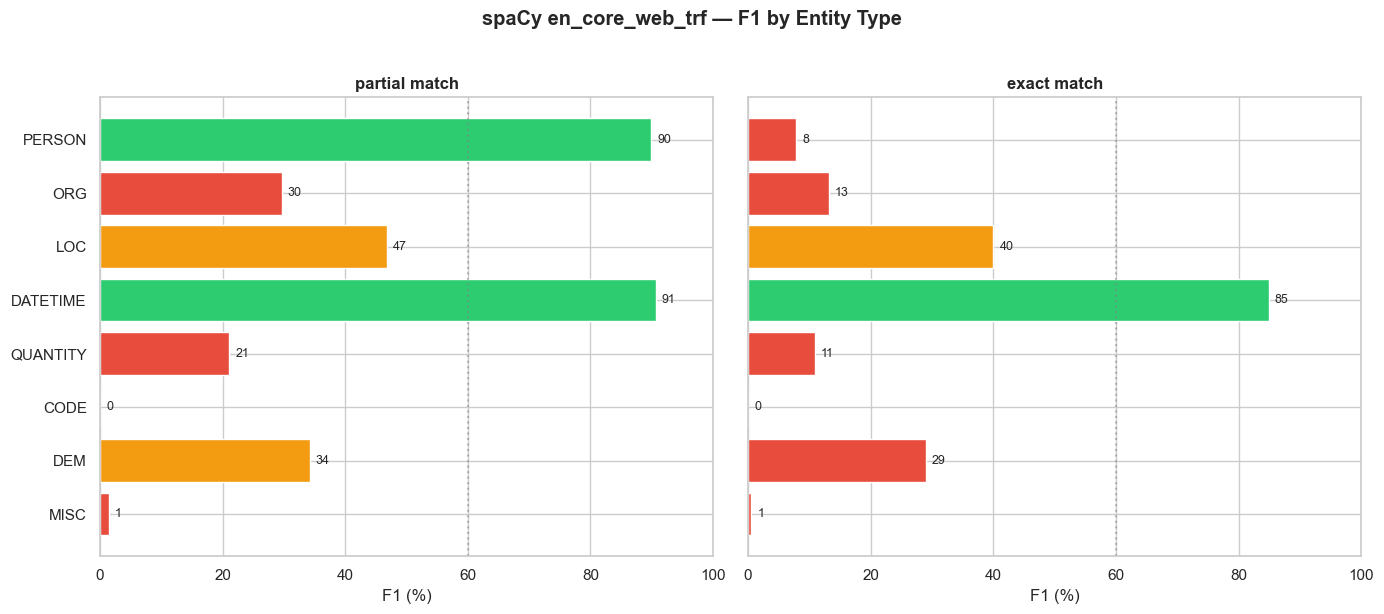

In [6]:
# F1 by entity type, side-by-side for partial vs exact
fig, axes = plt.subplots(1, len(MATCH_MODES), figsize=(7 * len(MATCH_MODES), 6), sharey=True)
if len(MATCH_MODES) == 1:
    axes = [axes]

entity_order = ["PERSON", "ORG", "LOC", "DATETIME", "QUANTITY", "CODE", "DEM", "MISC"]

for ax, mode in zip(axes, MATCH_MODES):
    merged = all_merged[mode]
    f1s = [merged[et].f1 * 100 for et in entity_order]
    colors = ["#e74c3c" if f < 30 else "#f39c12" if f < 60 else "#2ecc71" for f in f1s]
    ax.barh(entity_order[::-1], f1s[::-1], color=colors[::-1], edgecolor="white")
    for i, f in enumerate(f1s[::-1]):
        ax.text(f + 1, i, f"{f:.0f}", va="center", fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel("F1 (%)")
    ax.set_title(f"{mode} match", fontweight="bold")
    ax.axvline(x=60, color="grey", linestyle=":", alpha=0.5)

fig.suptitle(f"spaCy {SPACY_MODEL} — F1 by Entity Type", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("../figures/phase1_f1_scores.png", dpi=120, bbox_inches="tight")
plt.show()


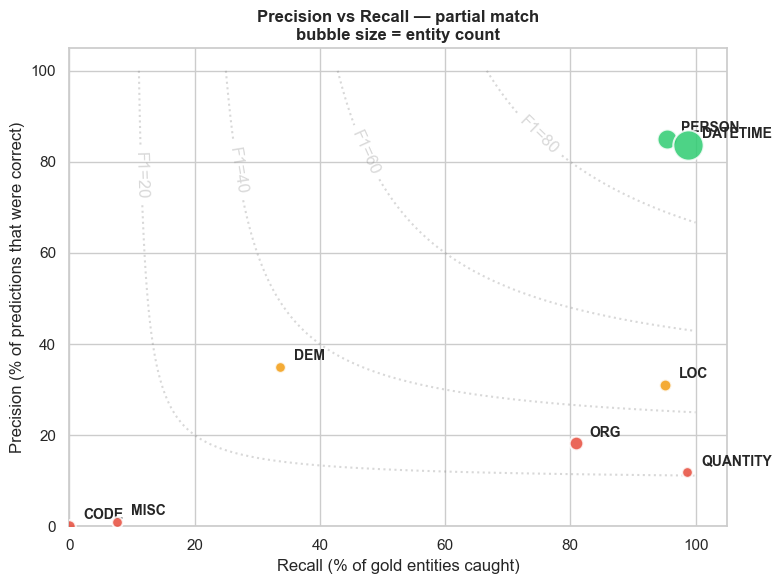

In [7]:
# Precision vs recall scatter
fig, ax = plt.subplots(figsize=(8, 6))
mode = MATCH_MODES[0]
merged = all_merged[mode]

for et in entity_order:
    r = merged[et]
    color = "#e74c3c" if r.f1 < 0.3 else "#f39c12" if r.f1 < 0.6 else "#2ecc71"
    size = max(60, min(500, (r.tp + r.fn) / 20))
    ax.scatter(r.recall * 100, r.precision * 100, s=size, c=color,
               edgecolors="white", linewidth=1.5, alpha=0.85, zorder=5)
    ax.annotate(et, (r.recall * 100, r.precision * 100),
                textcoords="offset points", xytext=(10, 5), fontsize=10, fontweight="bold")

# F1 contour lines
import numpy as np
xx, yy = np.meshgrid(np.linspace(1, 100, 100), np.linspace(1, 100, 100))
f1 = 2 * xx * yy / (xx + yy + 1e-9)
cs = ax.contour(xx, yy, f1, levels=[20, 40, 60, 80], colors="grey", alpha=0.3, linestyles=":")
ax.clabel(cs, fmt="F1=%d")

ax.set_xlim(0, 105); ax.set_ylim(0, 105)
ax.set_xlabel("Recall (% of gold entities caught)")
ax.set_ylabel("Precision (% of predictions that were correct)")
ax.set_title(f"Precision vs Recall — {mode} match\nbubble size = entity count", fontweight="bold")
fig.tight_layout()
fig.savefig("../figures/phase1_precision_recall.png", dpi=120, bbox_inches="tight")
plt.show()


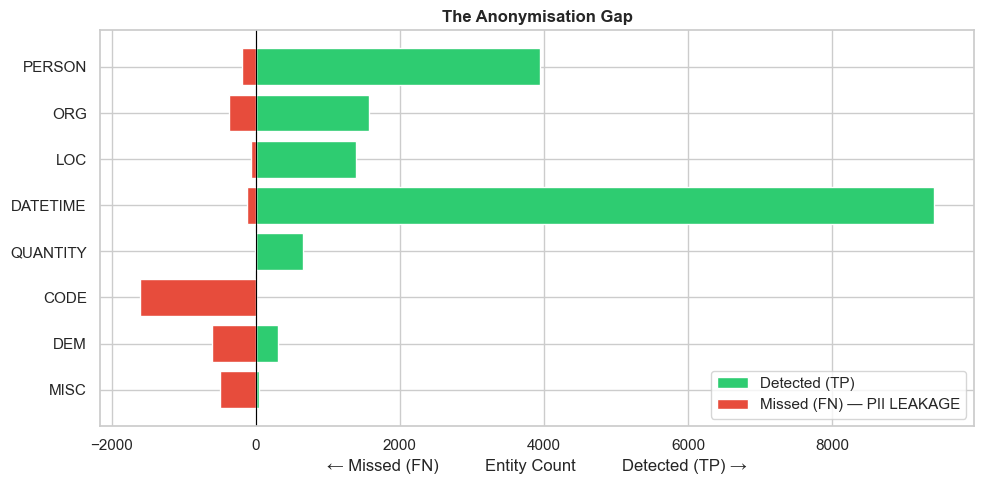

In [8]:
# The anonymisation gap — detected vs missed
fig, ax = plt.subplots(figsize=(10, 5))
mode = MATCH_MODES[0]
merged = all_merged[mode]
types = entity_order[::-1]
detected = [merged[et].tp for et in types]
missed = [merged[et].fn for et in types]

y = range(len(types))
ax.barh(y, detected, color="#2ecc71", label="Detected (TP)", edgecolor="white")
ax.barh(y, [-m for m in missed], color="#e74c3c", label="Missed (FN) — PII LEAKAGE", edgecolor="white")
ax.set_yticks(y); ax.set_yticklabels(types)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("← Missed (FN)          Entity Count          Detected (TP) →")
ax.set_title("The Anonymisation Gap", fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("../figures/phase1_gap_analysis.png", dpi=120, bbox_inches="tight")
plt.show()


## Failure analysis — what's leaking?

Numbers don't make the case as well as actual leaks do. Here are concrete examples of TAB entities that spaCy missed (PII that would survive a "naive" anonymisation pass) and false alarms that would frustrate a paralegal.


In [9]:
missed = defaultdict(list)
fps = defaultdict(list)

mode = MATCH_MODES[0]
for doc in test_docs[:200]:
    text = doc["text"]
    gold = extract_gold_entities(doc)
    pred = predict_entities(nlp, text)

    for gs, ge, gt, gtxt in gold:
        if not any(pt == gt and (ps < ge and pe > gs) for ps, pe, pt, _ in pred):
            ctx = text[max(0, gs - 60): min(len(text), ge + 60)]
            missed[gt].append({"span": gtxt, "context": ctx, "doc_id": doc["doc_id"]})

    for ps, pe, pt, ptxt in pred:
        if not any(pt == gt and (ps < ge and pe > gs) for gs, ge, gt, _ in gold):
            ctx = text[max(0, ps - 40): min(len(text), pe + 40)]
            fps[pt].append({"span": ptxt, "context": ctx})

print("MISSED ENTITIES — PII that would leak through")
print("=" * 70)
for et in ["CODE", "DEM", "PERSON", "LOC", "ORG"]:
    examples = missed.get(et, [])
    print(f"\n── {et} ── ({len(examples)} missed in 200-doc sample)")
    for ex in examples[:3]:
        print(f'  ❌ "{ex["span"]}"')
        print(textwrap.fill(f"     ...{ex['context']}...", width=90, subsequent_indent="        "))
        print()


MISSED ENTITIES — PII that would leak through

── CODE ── (327 missed in 200-doc sample)
  ❌ "36110/97"
     ...PROCEDURE  The case originated in an application (no. 36110/97) against the
        Republic of Turkey lodged with the European Co...

  ❌ "43185/98"
     ...PROCEDURE  The case originated in two applications (nos. 43185/98 and 43186/98)
        against the United Kingdom of Great Britain a...

  ❌ "43186/98"
     ... The case originated in two applications (nos. 43185/98 and 43186/98) against the
        United Kingdom of Great Britain and Northern I...


── DEM ── (309 missed in 200-doc sample)
  ❌ "consultant psychiatrist"
     ...The applicant in application no. 43185/98 (“Dr Price”) is a consultant
        psychiatrist; the applicant in application no. 43186/98 (“Mrs Lowe”) is ...

  ❌ "medical secretary"
     ...the applicant in application no. 43186/98 (“Mrs Lowe”) is a medical secretary.
        They live in Lincoln.  The applicants, together with Dr Pr...

  ❌ "docto

In [10]:
print("FALSE ALARMS — noise that wastes reviewer time")
print("=" * 70)
for et in ["ORG", "QUANTITY", "MISC"]:
    examples = fps.get(et, [])
    print(f"\n── {et} ── ({len(examples)} false alarms in 200-doc sample)")
    for ex in examples[:3]:
        print(f'  ⚠️  "{ex["span"]}"')
        print(textwrap.fill(f"     ...{ex['context']}...", width=90, subsequent_indent="        "))
        print()


FALSE ALARMS — noise that wastes reviewer time

── ORG ── (3115 false alarms in 200-doc sample)
  ⚠️  "the European Commission of Human Rights"
     ...inst the Republic of Turkey lodged with the European Commission of Human Rights
        (“the Commission”) under former Article...

  ⚠️  "Commission"
     ...ropean Commission of Human Rights (“the Commission”) under former Article 25 of
        the Conven...

  ⚠️  "The Turkish Government"
     .... Esmer, a lawyer practising in Ankara. The Turkish Government (“the Government”)
        did not designate an...


── QUANTITY ── (1829 false alarms in 200-doc sample)
  ⚠️  "36110/97"
     ... case originated in an application (no. 36110/97) against the Republic of Turkey
        lodged ...

  ⚠️  "four"
     ...damental Freedoms (“the Convention”) by four Turkish nationals, Mr Galip Yalman,
        Mr ...

  ⚠️  "First"
     ...case was assigned to the newly composed First Section (Rule 52 § 1).  By a
        decision o...


── MISC ── (2

## Try it yourself

The `demo_anonymise` helper takes a string and shows what spaCy detects, then renders the redacted version. Useful for the live demo and sanity-checking.


In [11]:
sample_text = test_docs[0]["text"][:800]
print("INPUT (first 800 chars):")
print(textwrap.fill(sample_text, width=90, initial_indent="  ", subsequent_indent="  "))
print()
result = demo_anonymise(sample_text, nlp)


INPUT (first 800 chars):
  PROCEDURE  The case originated in an application (no. 36110/97) against the Republic of
  Turkey lodged with the European Commission of Human Rights (“the Commission”) under
  former Article 25 of the Convention for the Protection of Human Rights and Fundamental
  Freedoms (“the Convention”) by four Turkish nationals, Mr Galip Yalman, Mr Bahattin
  Sarısoy, Mr Osman Çağlayan and Mr Yusuf Çamca (“the applicants”), on 29 November 1996.
  The applicants were represented by Mr S. Esmer, a lawyer practising in Ankara. The
  Turkish Government (“the Government”) did not designate an Agent for the purposes of the
  proceedings before the Convention institutions.  The applicants alleged that their case,
  which commenced in 1989 and terminated in 1996, was not heard within a reasonable time
  as required by the Co

ENTITIES DETECTED
  [CARDINAL   → QUANTITY  ] "36110/97"
  [GPE        → LOC       ] "the Republic of Turkey"
  [ORG        → ORG       ] "the European Co

In [12]:
# Paste your own text here:
my_text = """The applicant, Maria Petrova, is a 47-year-old Bulgarian national living in Plovdiv.
On 12 March 2018 she filed a complaint (Application no. 12345/67) against
Sofia District Court alleging discrimination on grounds of her Roma ethnicity.
"""
_ = demo_anonymise(my_text, nlp)


ENTITIES DETECTED
  [PERSON     → PERSON    ] "Maria Petrova"
  [DATE       → DATETIME  ] "47-year-old"
  [NORP       → DEM       ] "Bulgarian"
  [GPE        → LOC       ] "Plovdiv"
  [DATE       → DATETIME  ] "12 March 2018"
  [CARDINAL   → QUANTITY  ] "12345/67"
  [ORG        → ORG       ] "Sofia District Court"
  [NORP       → DEM       ] "Roma"

ANONYMISED OUTPUT
The applicant, [PERSON], is a [DATETIME] [DEM] national living in [LOC].
On [DATETIME] she filed a complaint (Application no. [QUANTITY]) against
[ORG] alleging discrimination on grounds of her [DEM] ethnicity.



## Where this leaves us

| Question | Answer |
|---|---|
| Is off-the-shelf NER enough to anonymise legal text? | **No.** Overall partial-match F1 ≈ 0.55–0.60. |
| What's missing entirely? | `CODE` (0% recall), most `DEM`, occupation/role identifiers in MISC. |
| What produces too much noise? | `ORG`, `QUANTITY`, `MISC` — thousands of false positives that swamp the signal. |
| How much risk does even a "good" redaction leave behind? | See **Notebook 03 — the mosaic effect**. The honest answer is *a lot*. |

That sets up the next two pieces of the project:

- **Notebook 03** quantifies the residual mosaic risk — even with a perfect NER, how often is a TAB document still uniquely identifiable from its quasi-identifiers alone?
- **Phase 2** (planned) compares this baseline against `dslim/bert-base-NER`, Microsoft Presidio, and a `roberta-base` fine-tuned on TAB train.
- **Phase 3** (planned) wraps the best model in the kind of pipeline a law firm could actually deploy: NER + regex + mosaic-risk scoring + audit log + human-in-the-loop fallback.
